In [ ]:
import os
import re
import shutil
import numpy as np
import glob
from tqdm.notebook import tqdm
from ioMicro import *
import torch
import napari

In [2]:
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated'
nFOV = 3

# 1. Rename incoming raw files

* From microscope, move new raw data into folder 'raw_incoming' inside wd

In [6]:
raw_files_dir= wd #+ os.sep + 'raw_incoming'
raw_files_n = raw_files_dir + '*\*.nd2'
raw_fls = glob.glob(raw_files_n)
fls = sorted(raw_fls, key=lambda t: os.stat(t).st_mtime)
fls_list = np.reshape(fls, (-1, nFOV))
print('(nhybs, nFoVs) =' , fls_list.shape)

(nhybs, nFoVs) = (34, 3)


* Double check the renaming is correct, then uncomment the 'os.rename' line and rerun the block 
* **There is no way back. Make sure the rename pattern is correct!**

In [4]:
offset = 0

if os.path.exists(wd+os.sep+'points.npz'):
    offset = np.load(wd+os.sep+'points.npz')['nhybs']
    
points = ['' for _ in range(fls_list.shape[1])]
import re
for ihyb in range(fls_list.shape[0]):
    for ifov in range(fls_list.shape[1]):
        src_fl = fls_list[ihyb, ifov]
        points[ifov] = re.search(r'Point([^_]+)_', src_fl).group(1)
        if not os.path.exists(src_fl): continue
        dst_fl = raw_files_dir + os.sep + 'hyb' + str(ihyb+offset+1).zfill(3) + '_Point' + points[ifov] + '.nd2'
        print(src_fl + '->' + dst_fl)
        os.rename(src_fl, dst_fl)

U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\R1_H1_Count00000_Count00000_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0000.nd2->U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\hyb001_Point0000.nd2
U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\R1_strip_Count00000_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0000.nd2->U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\hyb002_Point0000.nd2
U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\R1_H1_repeat_Count00000_Count00000_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0001.nd2->U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated\hyb003_Point0000.nd2
U:\Scientific Data\RG-A

## renaming based on first element

In [5]:
import os
import glob
import numpy as np
import re

raw_files_dir = wd  # Assuming 'wd' is defined elsewhere as the working directory
raw_files_n = raw_files_dir + '*\*.nd2'
raw_fls = glob.glob(raw_files_n)

# Helper function to convert found digits in the filename to integers for correct numerical sorting
def sort_key_func(t):
    # This regular expression will find all groups of digits in the filename and return the first group as an integer
    numbers = re.findall(r'\d+', t.split(os.sep)[-1])
    if numbers:
        return int(numbers[0])  # Return the first group of digits as an integer for sorting
    return t  # If no digits found, return the original string (fallback)

# Sort files based on the first set of digits found in the filename
fls = sorted(raw_fls, key=sort_key_func)

# Reshape files list into a 2D numpy array
fls_list = np.reshape(fls, (-1, nFOV))
print('(nhybs, nFoVs) =', fls_list.shape)

# Load offset if points.npz exists
offset = 0
if os.path.exists(wd + os.sep + 'points.npz'):
    offset = np.load(wd + os.sep + 'points.npz')['nhybs']

# Initialize points list
points = ['' for _ in range(fls_list.shape[1])]

# Renaming and moving files
for ihyb in range(fls_list.shape[0]):
    for ifov in range(fls_list.shape[1]):
        src_fl = fls_list[ihyb, ifov]
        point_match = re.search(r'Point([^_]+)_', src_fl)
        if point_match:
            points[ifov] = point_match.group(1)
        if not os.path.exists(src_fl):
            continue
        dst_fl = raw_files_dir + os.sep + 'hyb' + str(ihyb + offset + 1).zfill(3) + '_Point' + points[ifov] + '.nd2'
        
        # Added detailed print statement for each file renaming
        print(f'Filename:   {os.path.basename(src_fl)} will be now be:   {os.path.basename(dst_fl)}')
        
        os.rename(src_fl, dst_fl)


(nhybs, nFoVs) = (34, 3)
Filename:   Hyb1_Count00000_Count00000_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0008.nd2 will be now be:   hyb001_Point0000.nd2
Filename:   Hyb1_Count00000_Count00000_Point0001_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0009.nd2 will be now be:   hyb001_Point0001.nd2
Filename:   Hyb1_Count00000_Count00000_Point0002_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0010.nd2 will be now be:   hyb001_Point0002.nd2
Filename:   Hyb2_Count00000_Count00001_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0012.nd2 will be now be:   hyb002_Point0000.nd2
Filename:   Hyb2_Count00000_Count00001_Point0001_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0013.nd2 will be now be:   hyb002_Point0001.nd2
Filename:   Hyb2_Count00000_Count00001_Point0002_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0014.nd2 will be now be:   hyb002_Point0002.nd2
Filename:   Hyb3_Count00000_Point0000_ChannelSD Cy3,SD Cy5,SD DAPI_MB_Seq0000.nd2 will be now be:   hyb003_Point0000.nd2
Filename:   Hyb3_Count00000_Point0001_ChannelSD Cy3,SD Cy5,SD 

In [6]:
offset += fls_list.shape[0]
np.savez(wd+os.sep+'points.npz', points=points, nhybs=offset)

* Move all nd2 files into 'rawdata' folder
* Delete the empty subfolders in 'raw_incoming'

# 2. Drift Correction across rounds based on DAPI channel

In [ ]:
ch_dapi = 2 
points = np.load(wd+os.sep+'points.npz')['points']

In [8]:
drift_folder = wd + os.sep + 'drift_correction'
proj_folder = raw_files_dir +os.sep +'dapi_projections'
if not os.path.exists(proj_folder):
    os.mkdir(proj_folder)
if not os.path.exists(drift_folder):
    os.mkdir(drift_folder)

### 2.1 Detect features from DAPI channel and write out xy and xz projections. 
* This step can be done before all data were acquired

In [ ]:
import nd2
import tifffile

fls = np.sort(glob.glob(raw_files_dir + os.sep + '*.nd2'))
for f in fls:
    basename = os.path.basename(f).split('.')[0]
    if os.path.exists(drift_folder + os.sep + basename + '_DapiFeats.npz'):
        continue
    print(basename)
    
    im = nd2.imread(f, dask=True)
    im_dapi = np.array(im[:, ch_dapi])
    obj = get_dapi_features(im_dapi, drift_folder + os.sep + basename + '_DapiFeats.npz', psf_fl = 'psf_cy5.npy')
        
    tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
    tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))

hyb001_Point0000


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:44<00:00,  6.57s/it]
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:16: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:17: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))


hyb001_Point0001


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:32<00:00,  6.10s/it]
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:16: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:17: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))


hyb001_Point0002


...

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:37<00:00,  6.32s/it]
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:16: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:17: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))


hyb034_Point0001


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:44<00:00,  6.58s/it]
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:16: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:17: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))


hyb034_Point0002


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [02:56<00:00,  7.06s/it]
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:16: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xyProjection.tif', np.max(im_dapi, axis=0))
C:\Users\maysel0000\AppData\Local\Temp\ipykernel_13780\2807150096.py:17: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(proj_folder + os.sep + basename + '_DAPI_xzProjection.tif', np.max(im_dapi, axis=1))


* After this step, import the DAPI xy & yz projections in Fiji using "File -> Import -> Image Sequence" to visually check the extent of sample drift/distortion. This will also inform you if anything needs to be re-acquired

### 2.2 Drift correction. This should be done only after all data is acquired

In [ ]:
nhybs = np.load(wd+os.sep+'points.npz')['nhybs']
ref_hyb = 0
print('ref_hyb = ' + str(ref_hyb+1))

ref_hyb = 1


In [19]:
for fov in range(len(points)):   
    fls = np.sort(glob.glob(drift_folder + os.sep + '*' + points[fov] +'*_DapiFeats.npz'))
    rtxyz = []
    obj0 = get_dapi_features(None, fls[ref_hyb])
    for t in range(len(fls)):
        obj1 = get_dapi_features(None, fls[t])
        #txyz,txyzs = get_txyz(im_dapi0,im_dapi1,sz_norm=20,sz = 150,nelems=25,plt_val=False)
        tzxyf, cptzxy_plus, cptzxy_minus, Nplus, Nminus = get_txyz_dapi_features(obj0, obj1)
        rtxyz.append(tzxyf)
        print('Point' + points[fov] +', R' + str(t+1) + '-R' + str(ref_hyb+1) + ': ' + str(cptzxy_plus) + str(Nplus) + str(cptzxy_minus) + str(Nminus) + str(tzxyf))
    np.savez(drift_folder + os.sep + 'drift_correction_Point' + points[fov] + '.npz', rtxyz=rtxyz,fls=fls)

Point0000, R1-R1: [-0. -0. -0.]160409[-0. -0. -0.]122953[-0. -0. -0.]
Point0000, R2-R1: [1.7477309 2.0506177 1.5631657]126973[1.8821626 2.0130706 1.5623965]91530[1.8149467 2.0318441 1.5627811]
Point0000, R3-R1: [ 6.8292384 34.75345   36.403267 ]108173[ 6.9419003 34.682377  36.56679  ]77309[ 6.8855696 34.71791   36.48503  ]
Point0000, R4-R1: [ 2.6175537 33.818806  39.774544 ]109187[ 2.6554468 33.908054  39.939682 ]77255[ 2.6365004 33.86343   39.857113 ]
Point0000, R5-R1: [ 4.031135 32.559387 42.398117]117147[ 4.1831617 32.580643  42.60009  ]82256[ 4.107148 32.570015 42.499104]
Point0000, R6-R1: [ 2.7486503 30.299118  45.020832 ]118623[ 2.8727818 30.331728  45.242897 ]84418[ 2.8107162 30.315422  45.131866 ]
Point0000, R7-R1: [ 1.9635824 30.54627   45.575638 ]112166[ 2.1009057 30.638927  45.789253 ]78107[ 2.032244 30.592598 45.682446]
Point0000, R8-R1: [ 1.769677 26.574968 50.13456 ]88417[ 2.0449185 26.780283  50.280643 ]62992[ 1.9072978 26.677626  50.207603 ]
Point0000, R9-R1: [ 3.901892

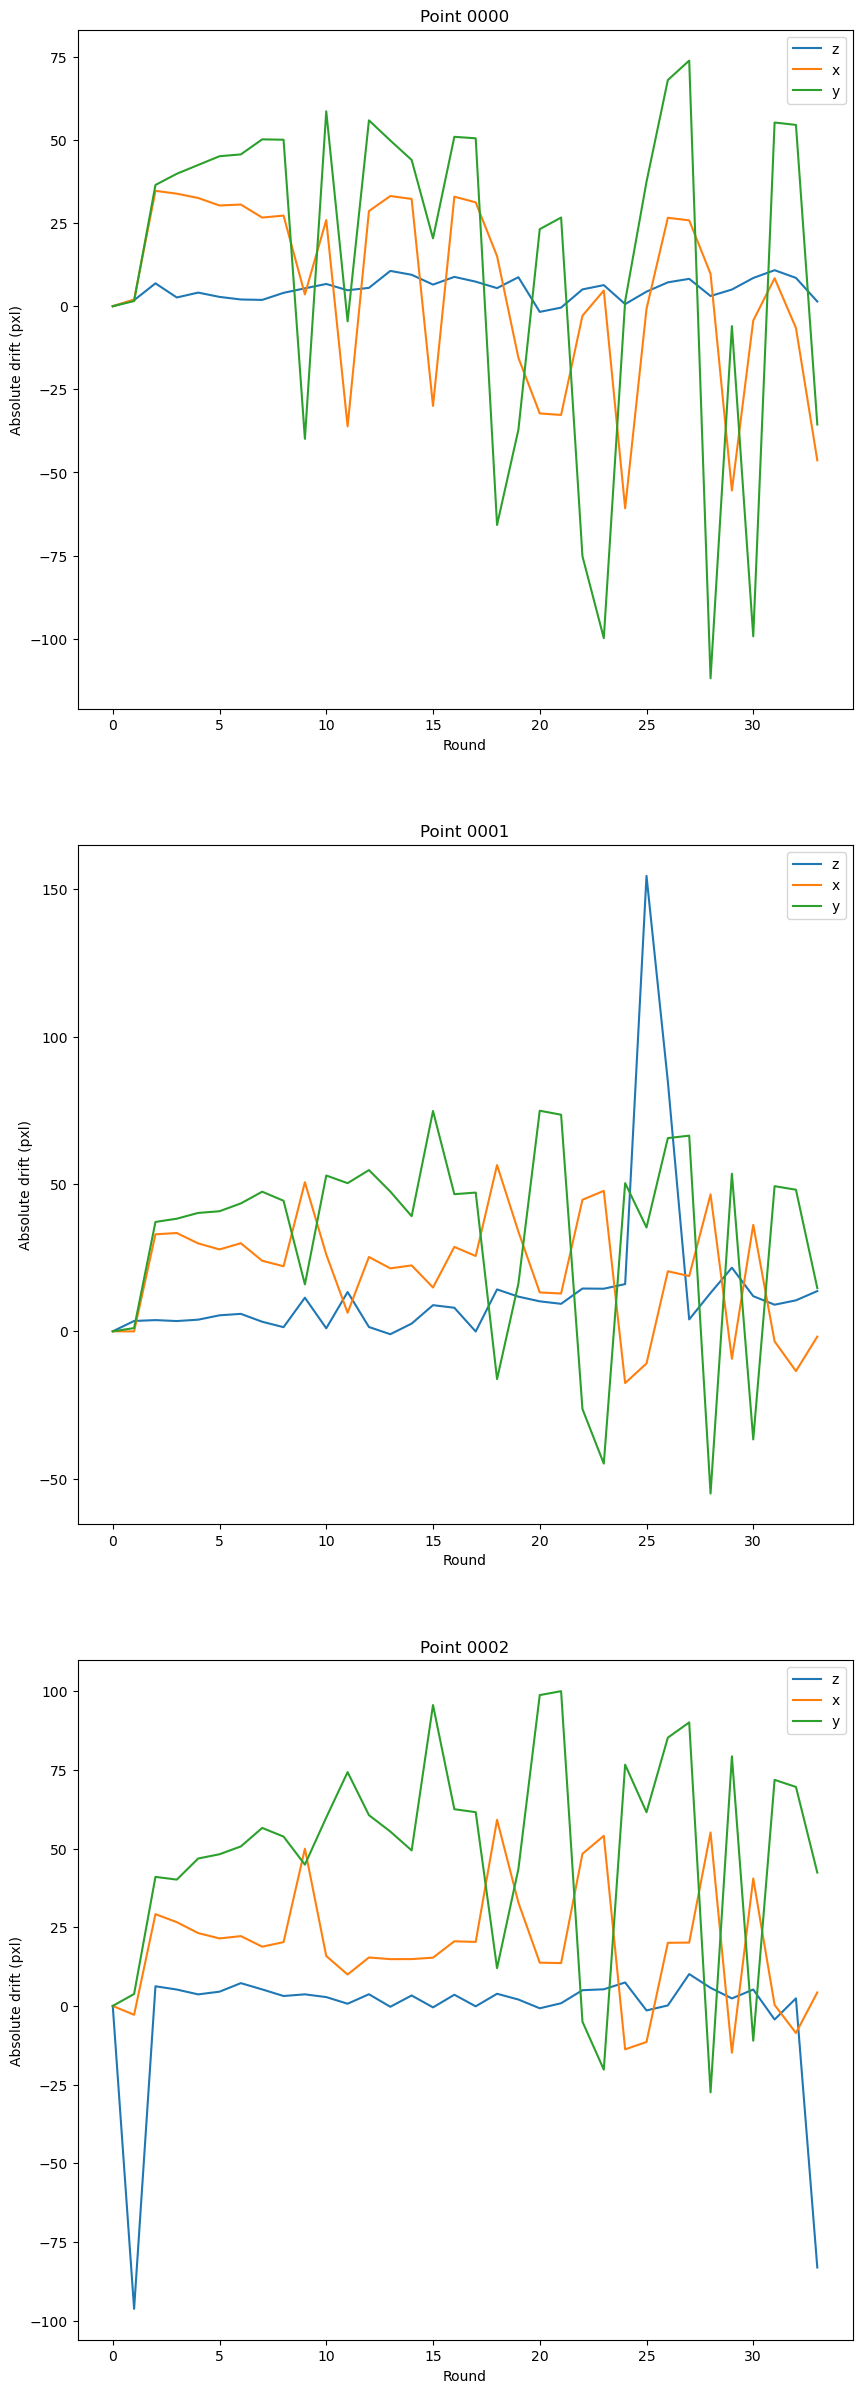

In [ ]:
import matplotlib.pyplot as plt

nrows = len(points)  # Set nrows to the number of elements in points

plt.subplots(nrows, 1, figsize=(10,10*nrows))
for fov in range(len(points)):
    rtxyz = np.load(drift_folder + os.sep + 'drift_correction_Point' + points[fov] + '.npz',allow_pickle=True)['rtxyz']
    plt.subplot(nrows, 1, fov+1)
    plt.plot(np.asarray(rtxyz))
    plt.legend(['z', 'x', 'y'])
    plt.xlabel('Round')
    plt.ylabel('Absolute drift (pxl)')
    plt.title('Point ' + points[fov])
plt.show()   

# 3. Register tiles using DAPI channel

In [24]:
nhyb = 1 #Preferrably use the round for cell segmentation
ch_dapi = 2
#raw_files_dir = wd + os.sep + 'rawdata'
points = np.load(wd+os.sep+'points.npz')['points']
res_dir = wd + os.sep + 'Result'
if not os.path.exists(res_dir):
    os.mkdir(res_dir)

## 4. Dot detection

In [7]:
import os
import numpy as np
#wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240325_seqFISH_multihyb\consolidated'
raw_files_dir= wd# + os.sep + 'rawdata'
result_dir = wd + os.sep + 'Result'
spot_dir = result_dir +  os.sep + 'called_spots'
if not os.path.exists(spot_dir):
    os.mkdir(spot_dir)
points = np.load(wd + os.sep + 'points.npz')['points']

In [8]:
dic_bM = dict()
dic_bM[0] = np.load('cy3_bM.npz')['bM']
dic_bM[1] = np.load('cy5_bM.npz')['bM']

In [9]:
import nd2
import glob 
from ioMicro import *

th_fit = 80
delta=2
delta_fit=4
sigmaZ=2.5
sigmaXY=1.85
for ip in range(len(points)): # for each Field of View
    print('processing fov ' + points[ip])
    fls = np.sort(glob.glob(raw_files_dir + os.sep + '*' + points[ip] +'*.nd2'))
    for t in range(len(fls)): #for each hyb
        if (os.path.exists(spot_dir + os.sep + 'hyb' +str(t+1).zfill(3) + '_Point' + points[ip] + '_ch2_th' + str(th_fit)+'.npz')) & (os.path.exists(spot_dir + os.sep + 'hyb' +str(t+1).zfill(3) + '_Point' + points[ip] + '_ch1_th' + str(th_fit)+'.npz')):     
            print('hyb '+str(t+1) +'exists')
            continue
        img = nd2.imread(fls[t], dask=True)
        for sig_ch in range(0, img.shape[1]-1):
            if (os.path.exists(spot_dir + os.sep + 'hyb' +str(t+1).zfill(3) + '_Point' + points[ip] + '_ch'+str(sig_ch)+'_th' + str(th_fit)+'.npz')):
                print('hyb '+str(t+1) + '_ch'+str(sig_ch) +'exists')
                continue
            im = np.array(img[:, sig_ch])
            im_ = np.array(im,dtype=np.float32)
            
            im_ = np.array([(im__-dic_bM[sig_ch][1])/dic_bM[sig_ch][0] for im__ in im_])
            #im_sig_ = norm_slice_ref(im1_sig,ref_ims[sig_ch], s=100)
            
            imD = full_deconv(im_,s_=500,pad=100,psf=np.load('psf_cy5.npy'),
                        parameters={'method': 'wiener', 'beta': 0.001, 'niter': 50},gpu=True,force=False)
            imDn = norm_slice(imD,s=100)
            
            
            #Xh = get_local_max_gaussian(im_sig_,th_fit,delta=delta,delta_fit=delta_fit,dbscan=True,sigmaZ=sigmaZ, sigmaXY=sigmaXY,
            #                return_centers=False,mins=None)
            Xh = get_local_maxfast_tensor(imDn,th_fit=th_fit,im_raw=im_,dic_psf=None,delta=delta,delta_fit=delta_fit,sigmaZ=sigmaZ,sigmaXY=sigmaXY)
            save_fit_fl = spot_dir + os.sep + 'hyb' +str(t+1).zfill(3) + '_Point' + points[ip] + '_ch' + str(sig_ch) + '_th' + str(th_fit)+'.npz'
            np.savez_compressed(save_fit_fl,Xh)
            # Explicitly delete large temporary variables to free memory
            del im, imD, imDn, Xh
            import gc
            gc.collect()

processing fov 0000


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:13<00:00, 12.56s/it]


hyb 1_ch1exists


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [04:32<00:00, 10.91s/it]


processing fov 0001


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [04:30<00:00, 10.80s/it]


processing fov 0002


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [04:31<00:00, 10.85s/it]


In [29]:
import os
import glob
import re
import numpy as np
import csv



def apply_transformation(spots, transformation_params):
    """
    Applies transformation parameters to spot coordinates. Currently supports translation.
    Future versions could support scaling and rotation.

    :param spots: Array of spot coordinates with shape (N, 3), where N is the number of spots.
    :param transformation_params: Transformation parameters [t_z, t_x, t_y, ...] for a given round.
    :return: Transformed spot coordinates.
    """
    # Validate inputs
    assert spots.shape[1] == 3, "Spots array must be of shape (N, 3)"
    assert len(transformation_params) >= 3, "Transformation parameters must include at least 3 values for translation"

    # Extract translation components
    t_z, t_x, t_y = transformation_params[:3]
    transformed_spots = np.copy(spots)
    transformed_spots[:, 0] += t_x
    transformed_spots[:, 1] += t_y
    transformed_spots[:, 2] += t_z

    # Placeholder for scaling/rotation
    # if len(transformation_params) > 3:
    #     # Implement scaling/rotation here
    #     pass

    return transformed_spots


# Load the parameters from the CSV file
file_path = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\gene_hyb__th_index.csv"
parameters = {}
spot_dir = r"U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots"

with open(file_path, mode='r') as file:
    # Detect the delimiter
    sample = file.read(1024)
    file.seek(0)
    dialect = csv.Sniffer().sniff(sample)
    reader = csv.reader(file, dialect)
    
    # Skip header
    next(reader)

    # Read and print the values
    for row in reader:
        if len(row) < 5:
            print(f"Skipping row with unexpected format: {row}")
            continue
        gene_name, nhyb, ch, b_th, cor_th = row
        parameters[(int(nhyb), int(ch))] = (int(b_th), float(cor_th))

# Ensure the output directory for NPZ files exists
thresholded_spots_dir = os.path.join(spot_dir, 'thresholded_spots')
if not os.path.exists(thresholded_spots_dir):
    os.makedirs(thresholded_spots_dir)

# Ensure the output directory for CSV files exists
thresholded_spots_csv_dir = os.path.join(spot_dir, 'thresholded_spots_csv')
if not os.path.exists(thresholded_spots_csv_dir):
    os.makedirs(thresholded_spots_csv_dir)

# Ensure the output directory for transformed downsampled CSV files exists
transformed_downsampled_dir = os.path.join(spot_dir, 'transformed_downsampled_csv')
if not os.path.exists(transformed_downsampled_dir):
    os.makedirs(transformed_downsampled_dir)

# Find all npz files in the spots directory
npz_files = glob.glob(os.path.join(spot_dir, '*.npz'))

for file in npz_files:
    # Load the data from the npz file
    print(file)
    data = np.load(file)['arr_0']
    base_name = os.path.basename(file)
    print(base_name)

    # Adjust the regex pattern
    match = re.search(r"hyb(\d+)_Point\d+_ch(\d+)_th\d+.npz", base_name)
    if match:
        hyb_num = int(match.group(1))
        ch_num = int(match.group(2))
        print(f"Hybridization: {hyb_num}, Channel: {ch_num}")
    else:
        print(f"Filename does not match expected format: {base_name}")
        continue

    # Look up the thresholds for this combination
    if (hyb_num, ch_num) not in parameters:
        print(f"No parameters found for hyb{hyb_num} ch{ch_num}.")
        continue

    b_th, cor_th = parameters[(hyb_num, ch_num)]

    # Apply the threshold conditions
    kp = (data[:, -3] > b_th) & (data[:, -4] > cor_th)
    filtered_data = data[kp]

    # Select only the first 3 columns from the filtered data
    filtered_data_first_3_columns = filtered_data[:, :3]

    # Transform and downsample spots
    transformed_spots = apply_transformation(filtered_data_first_3_columns, drift_data[hyb_num - 1])
    downsampled_spots = downsample_spots(transformed_spots)

    # Reorder columns from zxy to xyz
    downsampled_spots = downsampled_spots[:, [2, 0, 1]]

    # Construct new file names and paths for the thresholded data
    new_base_name = f"hyb{str(hyb_num).zfill(3)}_Point0000_ch{ch_num}_th{b_th}"
    
    ttd_csv_file_path = os.path.join(transformed_downsampled_dir, f"{new_base_name}_thresholded_transformed_downsampled.csv")
    new_npz_file_path = os.path.join(thresholded_spots_dir, f"{new_base_name}_thresholded.npz")
    new_csv_file_path = os.path.join(thresholded_spots_csv_dir, f"{new_base_name}_thresholded.csv")

    # Save the downsampled spots to a CSV file
    with open(ttd_csv_file_path, mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerows(downsampled_spots)

    # Save the filtered data to the new NPZ file
    np.savez_compressed(new_npz_file_path, filtered_data)

    # Save the first 3 columns of filtered data to the new CSV file
    with open(new_csv_file_path, mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerows(filtered_data_first_3_columns)

    print(f"Processed and saved thresholded data to: {new_npz_file_path}")
    print(f"Processed and saved first 3 columns of thresholded data as CSV to: {new_csv_file_path}")



U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\hyb001_Point0000_ch0_th80.npz
hyb001_Point0000_ch0_th80.npz
Hybridization: 1, Channel: 0
Processed and saved thresholded data to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\thresholded_spots\hyb001_Point0000_ch0_th120_thresholded.npz
Processed and saved first 3 columns of thresholded data as CSV to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\thresholded_spots_csv\hyb001_Point0000_ch0_th120_thresholded.csv
U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\hyb001_Point0000_ch1_th80.npz
hyb001_Point0000_ch1_th80.npz
Hybridization: 1, Channel: 1
Processed and sa

In [88]:
from scipy.ndimage import zoom

wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240114_seqFISH_fullRun'
raw_files_dir= wd + os.sep + 'rawdata'
result_dir = wd + os.sep + 'Result'
masks_file_path = result_dir + os.sep + 'hyb001_Point0000_downsampled_masks_3d_cp_masks.tif'  # Update this path to your mask TIFF file
masks = tifffile.imread(masks_file_path)
masks_scale_back = zoom(masks, (2, 2, 2),order=0)
# Add the original masks as labels
viewer.add_labels(masks_scale_back, name='Cell Masks')

<Labels layer 'Cell Masks' at 0x17f38c48990>

In [89]:
#applying drift correction and testing

def apply_transformation(spots, transformation_params):
    """
    Applies transformation parameters to spot coordinates. Currently supports translation.
    Future versions could support scaling and rotation.

    :param spots: Array of spot coordinates with shape (N, 3), where N is the number of spots.
    :param transformation_params: Transformation parameters [t_z, t_x, t_y, ...] for a given round.
    :return: Transformed spot coordinates.
    """
    # Validate inputs
    assert spots.shape[1] == 3, "Spots array must be of shape (N, 3)"
    assert len(transformation_params) >= 3, "Transformation parameters must include at least 3 values for translation"

    # Extract translation components
    t_z, t_x, t_y = transformation_params[:3]
    transformed_spots = np.copy(spots)
    transformed_spots[:, 0] += t_x
    transformed_spots[:, 1] += t_y
    transformed_spots[:, 2] += t_z

    # Placeholder for scaling/rotation
    # if len(transformation_params) > 3:
    #     # Implement scaling/rotation here
    #     pass

    return transformed_spots

wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240114_seqFISH_fullRun'
raw_files_dir= wd + os.sep + 'rawdata'
result_dir = wd + os.sep + 'Result'

# Define the paths to your files
drift_file_path = wd + os.sep + '\drift_correction\drift_correction_Point0000.npz'


# Load the called spots
#spots_data = np.load(spots_file_path)['arr_0']
spots = Xh[kp, :3]  # Assuming the first three columns are x, y, z

# Load the drift correction parameters
drift_data = np.load(drift_file_path)['rtxyz']
transformation_params = drift_data[nhyb-1]  

# Apply transformation to the loaded spots
transformed_spots = apply_transformation(spots, transformation_params)

viewer.add_points(transformed_spots, face_color=[0,0,0,0], edge_color='g', size=5, name='transformed_cor='+str(cor_th) + ', b=' +str(b_th),out_of_slice_display=True)

<Points layer 'transformed_cor=0.3, b=200' at 0x17f56060910>

In [ ]:
# assign spots to masks
def assign_spots_to_cells(spots, masks, scale_factor=1):
    """
    Assigns each spot to a cell based on provided masks, scaling the spot coordinates to match the mask scale.
    :param spots: Array of transformed spot coordinates with shape (N, 3), where N is the number of spots.
    :param masks: 3D array where each slice is a 2D mask of cells.
    :param scale_factor: Factor by which the original images were downsampled to create the masks.
    :return: DataFrame with spots and their assigned cell labels.
    """
    assigned_cells = []
    for spot in spots:
        # Scale x, y, and z coordinates to match the mask scale
        x_scaled = int(round(spot[0] * scale_factor))
        y_scaled = int(round(spot[1] * scale_factor))
        z_scaled = int(round(spot[2] * scale_factor))
        
        if 0 <= z_scaled < masks.shape[0] and 0 <= y_scaled < masks.shape[1] and 0 <= x_scaled < masks.shape[2]:
            cell_label = masks[z_scaled, y_scaled, x_scaled]
            assigned_cells.append(cell_label)
        else:
            assigned_cells.append(np.nan)  # Assign NaN if the spot's coordinates are out of bounds

    spots_df = pd.DataFrame(spots, columns=['X', 'Y', 'Z'])
    spots_df['Assigned_Cell'] = assigned_cells
    return spots_df

# Use the revised function to assign spots to cells
assigned_spots_df = assign_spots_to_cells(transformed_spots, masks_scale_back, scale_factor=1)
# Count the spots assigned to each cell
spot_counts = assigned_spots_df['Assigned_Cell'].value_counts()

# Normalize the spot counts to get values between 0 and 1 for coloring
max_count = spot_counts.max()
normalized_counts = spot_counts / max_count if max_count > 0 else spot_counts

# Create an intensity image based on the normalized spot counts
intensity_image = np.zeros_like(masks_scale_back, dtype=np.float32)
for cell_label in tqdm(spot_counts.index, desc="Processing Cells"):
    #start_time = time.time()
    intensity_image[masks == cell_label] = normalized_counts[cell_label]
    #print(f"Label {cell_label} processed in {time.time() - start_time} seconds.")
# Initialize Napari viewer
viewer = napari.Viewer()

# Add the original masks as labels
#viewer.add_labels(masks, name='Cell Masks')

# Add the intensity image as an overlay
# This layer uses the normalized spot counts to color each cell
viewer.add_image(intensity_image, colormap='viridis', name='Spot Count Intensity', blending='additive')



# 5. Cell segmentation -cellpose dapi

In [124]:
import napari
import nd2
import tifffile
import os
from scipy.ndimage import zoom

# Define the working directory and subdirectories
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated'
raw_files_dir = wd 
result_dir = wd + os.sep + 'Result'
nhyb = 1

# Define the list of FOV points

for ip in range(len(points)):  # for each Field of View
    p = points[ip]
    print(f'Processing FOV {p}')

    # Load the image
    img_path = os.path.join(raw_files_dir, f'hyb{str(nhyb).zfill(3)}_Point{p}.nd2')
    img = nd2.imread(img_path, dask=True)
    print(f'Image loaded: {img_path}')
    
    # Select the third channel
    im_ = img[:, 2]
    print(f'Original shape: {im_.shape}')

    # Downsample the image
    downsampled_im = zoom(im_, (0.5, 0.5, 0.5))
    output_path = os.path.join(result_dir, f'hyb{str(nhyb).zfill(3)}_Point{p}_downsampled.tif')
    tifffile.imsave(output_path, downsampled_im)
    print(f'Downsampled shape: {downsampled_im.shape}')
    print(f'Downsampled image saved to: {output_path}')


Processing FOV 0000
Image loaded: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\hyb001_Point0000.nd2
Original shape: (752, 2304, 2304)


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_10608\382412713.py:31: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(output_path, downsampled_im)


Downsampled shape: (376, 1152, 1152)
Downsampled image saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0000_downsampled.tif
Processing FOV 0001
Image loaded: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\hyb001_Point0001.nd2
Original shape: (752, 2304, 2304)


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_10608\382412713.py:31: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(output_path, downsampled_im)


Downsampled shape: (376, 1152, 1152)
Downsampled image saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0001_downsampled.tif
Processing FOV 0002
Image loaded: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\hyb001_Point0002.nd2
Original shape: (752, 2304, 2304)


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_10608\382412713.py:31: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(output_path, downsampled_im)


Downsampled shape: (376, 1152, 1152)
Downsampled image saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0002_downsampled.tif


## to train a model saving slices 

In [ ]:
import os
import tifffile

# Define the working directory and subdirectories
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated'
result_dir = wd + os.sep + 'Result'
zSlices_dir_base = result_dir + os.sep + 'zSlices_downsampledFact2'

# Ensure the base zSlices directory exists
if not os.path.exists(zSlices_dir_base):
    os.mkdir(zSlices_dir_base)

for ip in range(len(points)):  # for each Field of View
    p = points[ip]
    downsampled_file = os.path.join(result_dir, f'hyb001_Point{p}_downsampled.tif')
    
    print(f'Processing downsampled file: {downsampled_file}')
    downsampled_im = tifffile.imread(downsampled_file)

    # Create a subfolder for each point
    zSlices_dir = os.path.join(zSlices_dir_base, f'Point{p}')
    if not os.path.exists(zSlices_dir):
        os.mkdir(zSlices_dir)

    original_file_name = f'hyb001_Point{p}'

    # Iterate through every 10th z-slice
    for z in range(0, downsampled_im.shape[0], 10):
        slice_img = downsampled_im[z, :, :]  # Extract the z-th slice
        slice_file_name = f"{original_file_name}_downFact2_slice_{z}.tif"  # Naming each slice file
        slice_file_path = os.path.join(zSlices_dir, slice_file_name)
        tifffile.imsave(slice_file_path, slice_img)  # Save the slice
        print(f'Saved {slice_file_path}')

    print(f'Finished processing FOV {p}')


Processing downsampled file: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0000_downsampled.tif


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_10608\3525293493.py:35: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(slice_file_path, slice_img)  # Save the slice


Saved U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\hyb001_Point0000_downFact2_slice_0.tif
Saved U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\hyb001_Point0000_downFact2_slice_10.tif
Saved U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\hyb001_Point0000_downFact2_slice_20.tif
Saved U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\hyb001_Point0000_downFact2_slice_30.tif
Saved U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFa

In [3]:
#load saved downsampled image for cellpose segmentation
import tifffile
import os
import numpy as np
import glob
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240114_seqFISH_fullRun'
raw_files_dir= wd + os.sep + 'rawdata'
result_dir = wd + os.sep + 'Result'
points = np.load(wd + os.sep + 'points.npz')['points']
ref_hyb = 1 
for ip in range(len(points)): # for each Field of View
    fls = np.sort(glob.glob(raw_files_dir + os.sep + '*' + points[ip] +'*.nd2'))
    original_file_name = os.path.splitext(os.path.basename(fls[ref_hyb]))[0]
    downsampled_file_name = original_file_name + '_downsampled_factor2.tif'  # Create a filename for the downsampled image
    downsampled_file_path = os.path.join(result_dir, downsampled_file_name)  # Define the full file path
    downsampled_im = tifffile.imread(downsampled_file_path)
    print('Loaded downsampled image shape:', downsampled_im.shape)

Loaded downsampled image shape: (376, 1152, 1152)


## cell segmentation 

In [1]:
from cellpose import models, io
import napari
from skimage import img_as_ubyte
from pathlib import Path
import os
import glob
import numpy as np
import nd2

In [2]:
# Helper function to run the cellpose model
def run_cellpose_model_3D(
                       img,
                       do_3D = True,
                       model = 'cp',
                       pretrained_model = None,
                       cellprob_th = -20.0,
                       diameter = 12,
                       channels=[0,0],
                       use_GPU = True
                      ):
    logger = io.logger_setup()
    # Run cellpose model inference
    if pretrained_model:
        model = models.CellposeModel(gpu=use_GPU, pretrained_model=pretrained_model)
    else:
        model = models.CellposeModel(gpu=use_GPU, model_type=model)
    mask, flows, styles = model.eval(img, 
                                     channels=channels, 
                                     diameter=diameter, 
                                     do_3D=do_3D, 
                                     #net_avg=False, 
                                     #augment=False, 
                                     cellprob_threshold=cellprob_th,
                                    )
        
    return mask, flows, styles

def run_cellpose_model_2Dstitch(
                       img,
                       do_3D = False,
                       model = 'cp',
                       pretrained_model = None,
                       cellprob_th = -1.3,
                       flow_threshold = 0.0,
                       Stitch_threshold = -10.0,
                       diameter = 12,
                       channels=[0,0],
                       use_GPU = True
                      ):
    
    logger = io.logger_setup()
    # Run cellpose model inference
    if pretrained_model:
        model = models.CellposeModel(gpu=use_GPU, pretrained_model=pretrained_model)
    else:
        model = models.CellposeModel(gpu=use_GPU, model_type=model)
    
    mask, flows, styles = model.eval(img, 
                                     do_3D=do_3D, 
                                     channels=channels, 
                                     diameter=diameter, 
                                     #net_avg=False, 
                                     #augment=False, 
                                     cellprob_threshold=cellprob_th,
                                     flow_threshold=flow_threshold,
                                     stitch_threshold=Stitch_threshold, 
                                    )
        
    return mask, flows, styles

In [14]:
import tifffile
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated'
result_dir = wd + os.sep + 'Result'
downsampled_im = tifffile.imread(r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0002_downsampled.tif')

In [15]:
#cellpose parameters
diameter = 30
process_as_3D = True
channel = [0,0]
Stitch_threshold=0.25
cellprob_th=-1.3
flow_threshold = 0.8
pretrained_model = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\models\seqFISH_CP_202405_model'
nhyb = 1
p= 0000
# Use original_file_name to save a new file
# filename=result_dir + os.sep + 'hyb'+str(nhyb).zfill(3) + '_Point'+p+'_downsampled.tif'
filename = 'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\hyb001_Point0002_downsampled.tif'
original_file_name = os.path.splitext(os.path.basename(filename))[0]
mask_file_name = original_file_name.replace('.tif', '') + "_masks_3d.tif"
mask_file_path = os.path.join(result_dir, mask_file_name)

mask, flows, _ = run_cellpose_model_3D(downsampled_im, diameter=diameter, pretrained_model=pretrained_model,cellprob_th=cellprob_th)
# # Save the masks using the constructed save path
#io.masks_flows_to_seg(downsampled_im, mask, flows, diameter, mask_file_path, channel)
io.save_masks(downsampled_im, mask, flows, mask_file_path, png=False, tif=True)
            


creating new log file
2024-05-07 09:55:52,047 [INFO] WRITING LOG OUTPUT TO C:\Users\maysel0000\.cellpose\run.log
2024-05-07 09:55:52,047 [INFO] 
cellpose version: 	2.2.3 
platform:       	win32 
python version: 	3.11.7 
torch version:  	2.1.2
2024-05-07 09:55:52,080 [INFO] >>>> loading model U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\zSlices_downsampledFact2\Point0000\models\seqFISH_CP_202405_model
2024-05-07 09:55:52,097 [INFO] ** TORCH CUDA version installed and working. **
2024-05-07 09:55:52,097 [INFO] >>>> using GPU
2024-05-07 09:55:53,166 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2024-05-07 09:55:53,166 [INFO] >>>> model diam_labels =  38.889 (mean diameter of training ROIs)
2024-05-07 09:55:53,306 [INFO] multi-stack tiff read in as having 376 planes 1 channels
2024-05-07 09:56:17,456 [INFO] running YX: 376 planes of size (1152, 1152)
2024-05-07 09:59:35